### Configuration, inputs & outputs

In [1]:
from pipeline_utils import make_case1_paths
import pandas as pd
import numpy as np

# Configure paths
paths = make_case1_paths()

PROJECT_DIR = paths["project"]
RAW_DIR = paths["raw_uhn"]
PROC_DIR = paths["proc"]
RESULTS_DIR = paths["results"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROC_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Input files
doubling_time_file = PROC_DIR / "model_doubling_times_breast.csv"
rna_file = RAW_DIR / "uhn_breast" / "RNASeq_matrix.csv"
gene_info_file = RAW_DIR / "uhn_breast" / "RNASeq_gene_annotation.csv"

dt_df = pd.read_csv(
    doubling_time_file,
    usecols=["modelID", "doubling_time_days"],
    index_col="modelID"
)

rna_df = pd.read_csv(rna_file,index_col=0)

gene_info_df = pd.read_csv(
    gene_info_file
)

print(f"Doubling-time file: {doubling_time_file}")
print(f"RNA file: {rna_file}")
print(f"Gene-info file: {gene_info_file}")

# Output files
merged_table = PROC_DIR / "rna_doubling_time_merged_breast.csv"
plot_dt = RESULTS_DIR / "figure2c_DT_breast.png"
integration_qc_table = PROC_DIR / "rna_doubling_time_integration_qc_breast.csv"

Project directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Raw data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/0_datasets
Processed data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate
Results directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate
Doubling-time file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/model_doubling_times_breast.csv
RNA file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/0_datasets/uhn_breast/RNASeq_matrix.csv
Gene-info file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/0_datasets/uhn_breast/RNASeq_gene_annotation.csv


### Filter RNA-seq data and Merge with doubling time data

- restrict to protein-coding genes
- log2 transformation
- remove zero-variance genes
- merge RNA with doubling time

In [2]:
protein_coding_genes = set(gene_info_df.loc[gene_info_df["description"] == "protein_coding", "hugo.id"])

# Samples as rows, genes as columns
rna_df = rna_df.T

if rna_df.columns.duplicated().any():
    rna_df = rna_df.T.groupby(level=0).mean().T

# select protein coding gene
rna_df = rna_df.loc[:, rna_df.columns.isin(protein_coding_genes)]

# Restrict to samples that will actually enter the analysis
common_models = rna_df.index.intersection(dt_df.index)
rna_model_df = rna_df.loc[common_models].copy()

# Low-expression filter on the original TPM/FPKM scale
min_expression = 1.0
min_fraction = 0.20
min_samples = max(3, int(np.ceil(min_fraction * len(rna_model_df))))

expressed_genes = (
    (rna_model_df >= min_expression).sum(axis=0) >= min_samples
)

rna_model_df = rna_model_df.loc[:, expressed_genes]

print(f"Minimum required samples: {min_samples}")
print(f"Genes retained after expression filter: {rna_model_df.shape[1]}")

# Log transformation
rna_log_df = np.log2(rna_model_df + 1)

# Protect against constants and floating-point-level variation
rna_log_df = rna_log_df.loc[
    :, rna_log_df.var(axis=0, ddof=0) > 1e-8
]

merged_df = rna_log_df.join(dt_df, how="inner")

merged_df.to_csv(merged_table)
print(f"rna and doubling time merged table saved: {merged_table}")

rna_only_models = sorted(set(rna_log_df.index) - set(dt_df.index))
dt_only_models = sorted(set(dt_df.index) - set(rna_log_df.index))

print(f"Models in DT list: {dt_df.shape[0]}")
print(f"Models in final RNA + DT matrix: {merged_df.shape[0]}")
print(f"Protein-coding genes after variance filter: {rna_log_df.shape[1]}")
print(f"RNA models without DT: {len(rna_only_models)}")
print(f"DT models without RNA: {len(dt_only_models)}")
print(f"Final matrix shape: {merged_df.shape}")

Minimum required samples: 15
Genes retained after expression filter: 14070
rna and doubling time merged table saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_merged_breast.csv
Models in DT list: 96
Models in final RNA + DT matrix: 75
Protein-coding genes after variance filter: 14070
RNA models without DT: 0
DT models without RNA: 21
Final matrix shape: (75, 14071)


### Visualize doubling-time distribution for RNA-seq-matched PDX models (Figure 2c)

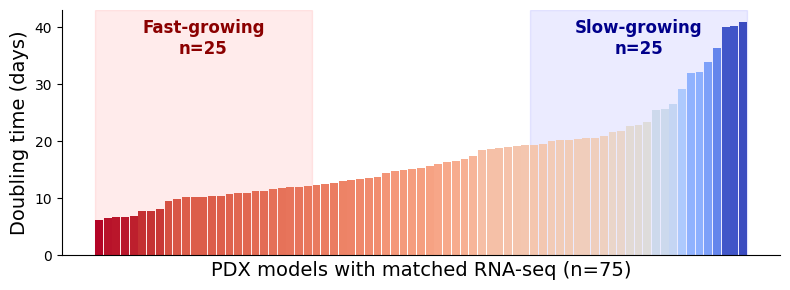

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plot_df = (
    merged_df[["doubling_time_days"]]
    .copy()
    .sort_values("doubling_time_days")
    .reset_index(drop=True)
)

n_models = len(plot_df)

low_cutoff = plot_df["doubling_time_days"].quantile(0.33)
high_cutoff = plot_df["doubling_time_days"].quantile(0.67)

fast_mask = plot_df["doubling_time_days"] <= low_cutoff
slow_mask = plot_df["doubling_time_days"] >= high_cutoff

norm = mcolors.Normalize(
    vmin=plot_df["doubling_time_days"].min(),
    vmax=plot_df["doubling_time_days"].max(),
)
cmap = plt.get_cmap("coolwarm_r")
bar_colors = [cmap(norm(v)) for v in plot_df["doubling_time_days"]]

fig, ax = plt.subplots(figsize=(8, 3))

ax.bar(
    x=np.arange(n_models),
    height=plot_df["doubling_time_days"],
    color=bar_colors,
    width=0.9,
)

fast_idx = np.where(fast_mask)[0]
slow_idx = np.where(slow_mask)[0]

ax.axvspan(fast_idx.min() - 0.5, fast_idx.max() + 0.5, color="red", alpha=0.08, zorder=0)
ax.axvspan(slow_idx.min() - 0.5, slow_idx.max() + 0.5, color="blue", alpha=0.08, zorder=0)

ax.text(
    fast_idx.mean(),
    ax.get_ylim()[1] * 0.82,
    f"Fast-growing\nn={fast_mask.sum()}",
    color="darkred",
    weight="bold",
    ha="center",
    fontsize=12,
)

ax.text(
    slow_idx.mean(),
    ax.get_ylim()[1] * 0.82,
    f"Slow-growing\nn={slow_mask.sum()}",
    color="darkblue",
    weight="bold",
    ha="center",
    fontsize=12,
)

ax.set_xticks([])
ax.set_ylabel("Doubling time (days)", fontsize=14)
ax.set_xlabel(f"Breast PDX models (n={n_models})", fontsize=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(plot_dt, dpi=300, bbox_inches="tight")
plt.show()

### QC summary for merged dataset

In [4]:
integration_qc = pd.Series({
    "rna_models_before_merge": rna_df.shape[0],
    "dt_models": dt_df.shape[0],
    "merged_models": merged_df.shape[0],
    "protein_coding_genes": rna_log_df.shape[1],
    "rna_models_without_dt": len(rna_only_models),
    "dt_models_without_rna": len(dt_only_models),
})
integration_qc.to_csv(integration_qc_table, header=["value"])

print(f"savevd integration qc table to {integration_qc_table}")
print(integration_qc)

savevd integration qc table to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_integration_qc_breast.csv
rna_models_before_merge       95
dt_models                     96
merged_models                 75
protein_coding_genes       14070
rna_models_without_dt          0
dt_models_without_rna         21
dtype: int64
